# ═══════════════════════════
# Import Dataset 
# ═══════════════════════════

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('economic_dataset_completed.csv')
df

,year,exports_pct,fdi_pct_gdp,inflation_gd,net_exports,gross_investment,real_premium,gdp_growth,unemployment rate,population growth
0,1990,NaN,8.563300,145.629900,-35.538700,17.491300,-58.824800,1.1623,1.900000,4.260000
1,1991,NaN,8.563300,107.440100,-33.163500,17.491300,-48.134700,7.5913,1.900000,4.230000
2,1992,NaN,7.967667,95.143222,-30.788367,16.895656,-41.267833,7.1000,1.824444,3.937778
3,1993,16.0562,7.372033,82.846344,-28.413233,16.300011,-34.400967,4.0000,1.748889,3.645556
4,1994,17.9134,6.776400,70.549467,-26.038100,15.704367,-27.534100,8.2000,1.673333,3.353333
5,1995,21.5197,6.180767,58.252589,-23.662967,15.108722,-20.667233,6.0000,1.597778,3.061111
6,1996,23.1115,5.585133,45.955711,-21.287833,14.513078,-13.800367,5.9000,1.522222,2.768889
7,1997,24.6288,4.989500,33.658833,-18.912700,13.917433,-6.933500,4.0000,1.446667,2.476667
8,1998,25.8193,4.393867,21.361956,-16.537567,13.321789,-0.066633,4.7000,1.371111,2.184444
9,1999,27.0214,3.798233,9.065078,-14.162433,12.726144,6.800233,12.7000,1.295556,1.892222


# ═══════════════════════════
# Information of Dataset 
# ═══════════════════════════

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                35 non-null     int64  
 1   exports_pct         32 non-null     float64
 2   fdi_pct_gdp         35 non-null     float64
 3   inflation_gd        35 non-null     float64
 4   net_exports         35 non-null     float64
 5   gross_investment    35 non-null     float64
 6   real_premium        35 non-null     float64
 7   gdp_growth          35 non-null     float64
 8   unemployment rate   35 non-null     float64
 9   population growth   35 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 2.9 KB


# ═══════════════════════════
# Checking Missing value 
# ═══════════════════════════

In [4]:
# Checking missing value 
df.isnull().sum()

year                  0
exports_pct           3
fdi_pct_gdp           0
inflation_gd          0
net_exports           0
gross_investment      0
real_premium          0
gdp_growth            0
unemployment rate     0
population growth     0
dtype: int64

# ═══════════════════════════
#  Calculating Skewness
# ═══════════════════════════

In [5]:
# fill missing value by using skewness 
from scipy.stats import skew
sk = skew(df['exports_pct'].dropna())
print("Skewness of export  =", sk)

#Boxplot 

#making decision of numerical method.
mean_export = df["exports_pct"].mean()
median_export = df["exports_pct"].median()
print("Mean export =", mean_export)
print("Median export =", median_export)




Skewness of export  = -0.9555675230062205
Mean export = 51.318068749999995
Median export = 55.85685


# ═══════════════════════════
# Descision making on mean or median 
# ═══════════════════════════

In [6]:
# fill missing values in numeric columns with their median
df['exports_pct'] = df['exports_pct'].fillna(df['exports_pct'].median())
df

,year,exports_pct,fdi_pct_gdp,inflation_gd,net_exports,gross_investment,real_premium,gdp_growth,unemployment rate,population growth
0,1990,55.85685,8.563300,145.629900,-35.538700,17.491300,-58.824800,1.1623,1.900000,4.260000
1,1991,55.85685,8.563300,107.440100,-33.163500,17.491300,-48.134700,7.5913,1.900000,4.230000
2,1992,55.85685,7.967667,95.143222,-30.788367,16.895656,-41.267833,7.1000,1.824444,3.937778
3,1993,16.05620,7.372033,82.846344,-28.413233,16.300011,-34.400967,4.0000,1.748889,3.645556
4,1994,17.91340,6.776400,70.549467,-26.038100,15.704367,-27.534100,8.2000,1.673333,3.353333
5,1995,21.51970,6.180767,58.252589,-23.662967,15.108722,-20.667233,6.0000,1.597778,3.061111
6,1996,23.11150,5.585133,45.955711,-21.287833,14.513078,-13.800367,5.9000,1.522222,2.768889
7,1997,24.62880,4.989500,33.658833,-18.912700,13.917433,-6.933500,4.0000,1.446667,2.476667
8,1998,25.81930,4.393867,21.361956,-16.537567,13.321789,-0.066633,4.7000,1.371111,2.184444
9,1999,27.02140,3.798233,9.065078,-14.162433,12.726144,6.800233,12.7000,1.295556,1.892222


In [7]:
df.isnull().sum()

year                  0
exports_pct           0
fdi_pct_gdp           0
inflation_gd          0
net_exports           0
gross_investment      0
real_premium          0
gdp_growth            0
unemployment rate     0
population growth     0
dtype: int64

# ═══════════════════════════
# Exploritory Data Analytic 
# ═══════════════════════════

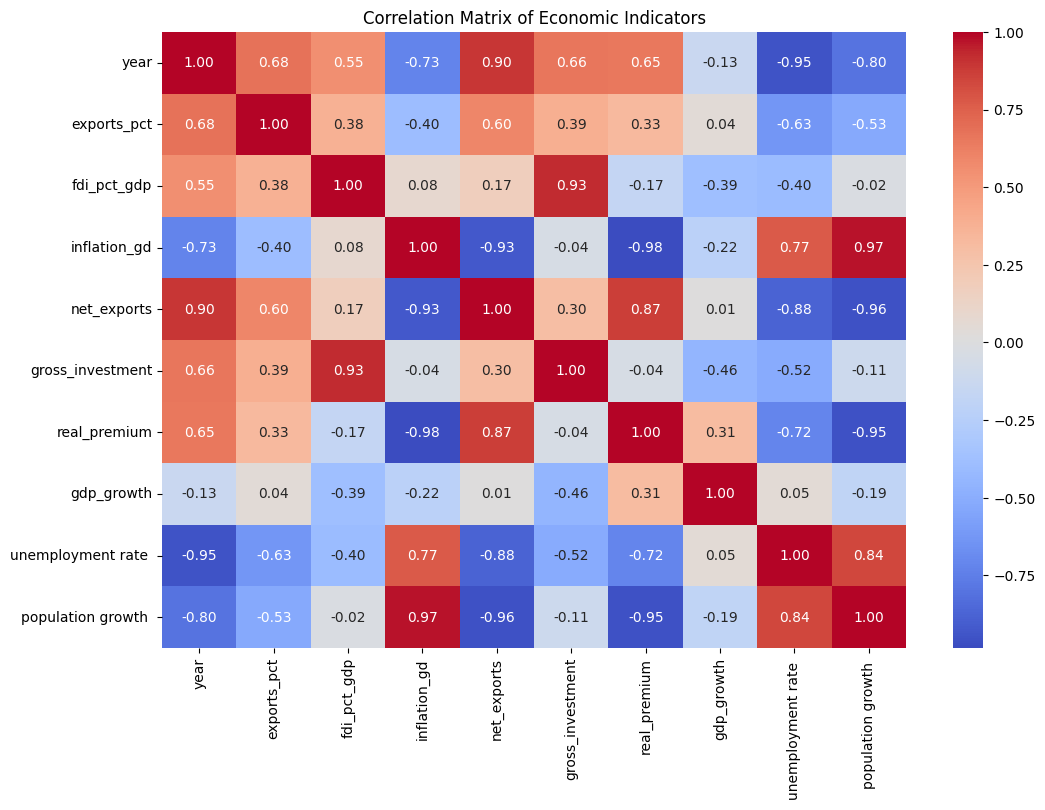

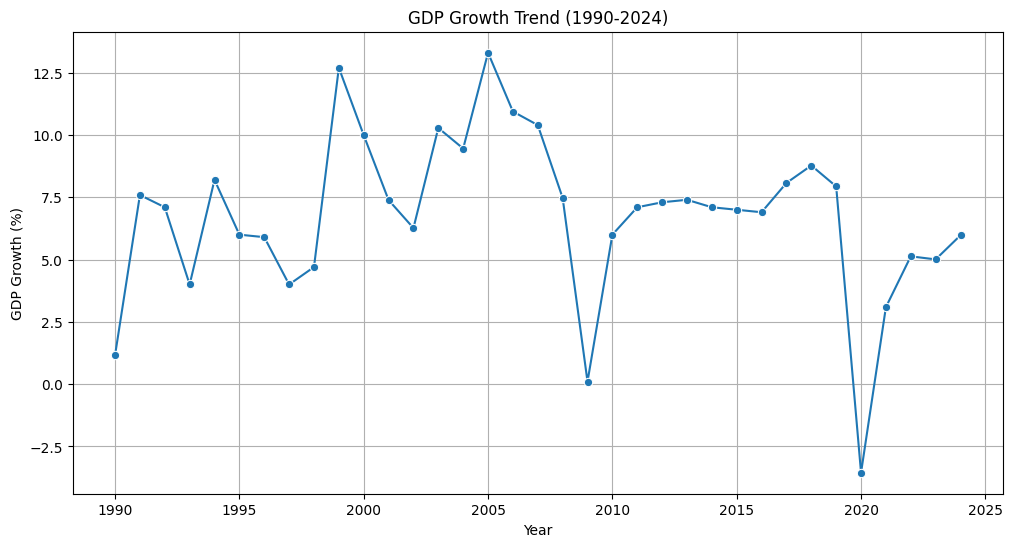

In [8]:
# EDA 

# 5. Correlation Analysis
# Create a heatmap to see relationships between variables
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Economic Indicators")
plt.show()

# 6. Time Series Analysis
# Visualizing trends over time
if 'year' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='year', y='gdp_growth', marker='o')
    plt.title("GDP Growth Trend (1990-2024)")
    plt.xlabel("Year")
    plt.ylabel("GDP Growth (%)")
    plt.grid(True)
    plt.show()

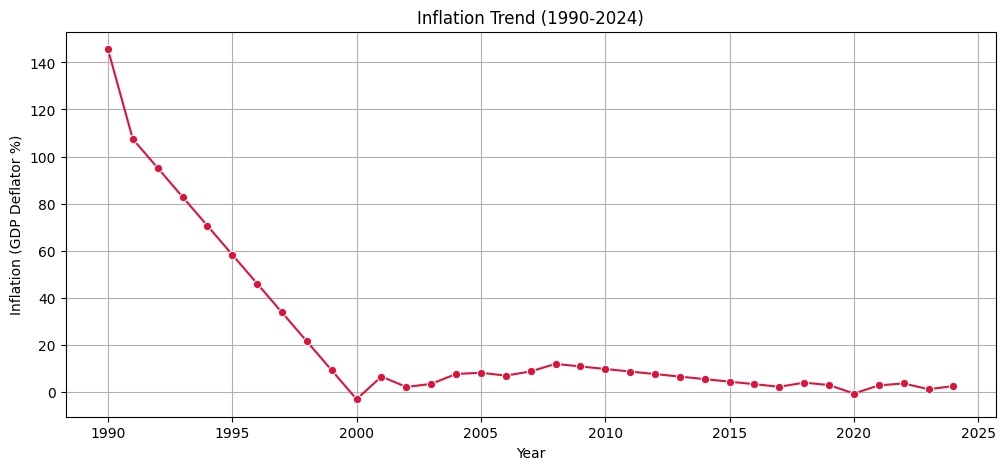

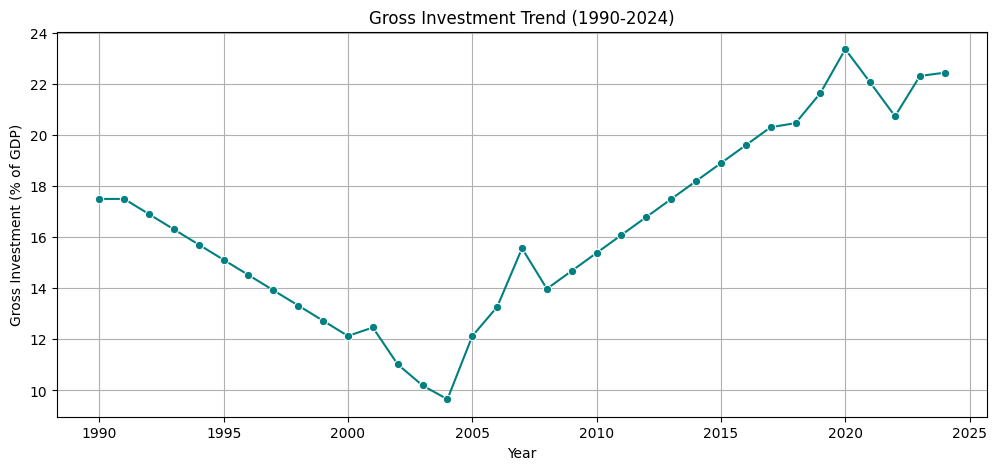

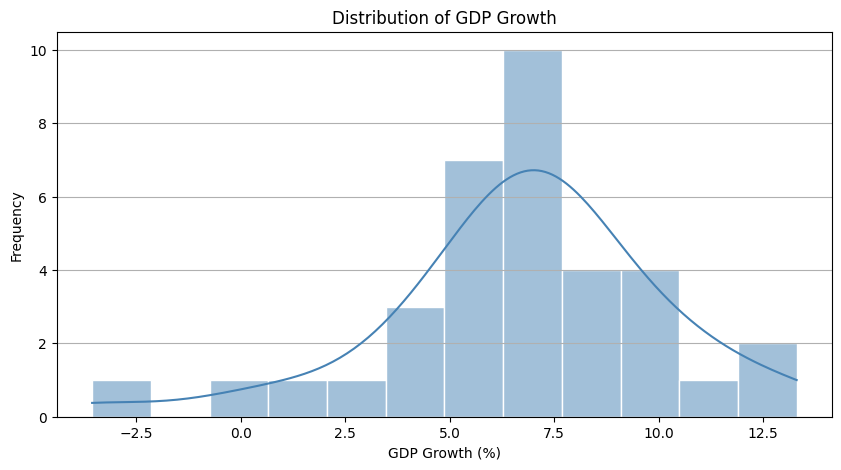

In [9]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='year', y='inflation_gd', marker='o', color='crimson')
plt.title("Inflation Trend (1990-2024)")
plt.xlabel("Year")
plt.ylabel("Inflation (GDP Deflator %)")
plt.grid(True)
plt.show()

# Plot 2: Gross Investment Trends Over Time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='year', y='gross_investment', marker='o', color='teal')
plt.title("Gross Investment Trend (1990-2024)")
plt.xlabel("Year")
plt.ylabel("Gross Investment (% of GDP)")
plt.grid(True)
plt.show()

# Plot 3: Distribution of GDP Growth
plt.figure(figsize=(10, 5))
sns.histplot(df['gdp_growth'], bins=12, kde=True, color='steelblue', edgecolor='white')
plt.title("Distribution of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.grid(True, axis='y')
plt.show()

# ═══════════════════════════
# Linear Regression
# ═══════════════════════════

In [10]:
# Build model for Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 2. Select Features and Target
# Excluding 'year' as it is a time index, not a direct economic feature
features = [col for col in df.columns if col not in ['year', 'gdp_growth']]
X = df[features]
y = df['gdp_growth']

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6. Evaluate
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Display feature importance
feature_importance = pd.Series(model.coef_, index=features).sort_values(ascending=False)
print("\nFeature Coefficients (Impact on GDP Growth):")
print(feature_importance)

Model Performance:
Mean Squared Error: 7.1147
R-squared Score: 0.4868

Feature Coefficients (Impact on GDP Growth):
real_premium          10.658155
population growth      6.840646
fdi_pct_gdp            4.080983
inflation_gd           3.821724
exports_pct            1.582508
net_exports           -0.010984
unemployment rate     -0.983242
gross_investment      -5.147301
dtype: float64


# ═══════════════════════════
# R-Square Train and Test of Linear Regression 
# ═══════════════════════════

In [11]:
# Assuming your data is already loaded as 'df' and preprocessed
from sklearn.metrics import r2_score

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate R^2
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R^2: {train_r2:.4f}")
print(f"Testing R^2: {test_r2:.4f}")

Training R^2: 0.6256
Testing R^2: 0.4868


# ═══════════════════════════
# Ridge - Regression and R-square 
# ═══════════════════════════

In [12]:
#Build Ridge regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale features (Required for Ridge Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Build and train the Ridge model
# 'alpha' is the regularization strength. 1.0 is a standard starting point.
ridge_model = Ridge(alpha= 0.01)
ridge_model.fit(X_train_scaled, y_train)

# 7. Evaluate
train_pred = ridge_model.predict(X_train_scaled)
test_pred = ridge_model.predict(X_test_scaled)

print(f"Ridge Regression - Training R^2: {r2_score(y_train, train_pred):.4f}")
print(f"Ridge Regression - Testing R^2: {r2_score(y_test, test_pred):.4f}")

Ridge Regression - Training R^2: 0.6249
Ridge Regression - Testing R^2: 0.4912


# ═══════════════════════════
# Lasso Regression 
# ═══════════════════════════

In [13]:

from sklearn.linear_model import Lasso

# Build and train the Lasso model
# Adjust 'alpha' to control how aggressive the feature selection is
lasso_model = Lasso(alpha=0.01) 
lasso_model.fit(X_train_scaled, y_train)

# Evaluate
train_pred = lasso_model.predict(X_train_scaled)
test_pred = lasso_model.predict(X_test_scaled)

print(f"Lasso Regression - Training R^2: {r2_score(y_train, train_pred):.4f}")
print(f"Lasso Regression - Testing R^2: {r2_score(y_test, test_pred):.4f}")

# Check which features Lasso 'killed' (coefficients set to 0)
features_selected = pd.DataFrame({'Feature': features, 'Coefficient': lasso_model.coef_})
print(features_selected)

Lasso Regression - Training R^2: 0.6161
Lasso Regression - Testing R^2: 0.4974
              Feature  Coefficient
0         exports_pct     1.482050
1         fdi_pct_gdp     3.126696
2        inflation_gd     1.792006
3         net_exports    -1.972471
4    gross_investment    -3.860410
5        real_premium     7.697056
6  unemployment rate     -0.337051
7  population growth      3.655396


# ═══════════════════════════
# R-square Test and Train of Lasso Regression 
# ═══════════════════════════

In [14]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest is non-linear and powerful
# 'n_estimators' is how many trees to build
# 'max_depth' limits how deep the trees go (prevents overfitting)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest doesn't strictly need scaling

# Predict and evaluate
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print(f"Random Forest Training R^2: {r2_score(y_train, train_pred):.4f}")
print(f"Random Forest Testing R^2: {r2_score(y_test, test_pred):.4f}")

Random Forest Training R^2: 0.6652
Random Forest Testing R^2: 0.3268


# ═══════════════════════════
# Summerize overall R-square of each model 
# ═══════════════════════════

In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Setup and Preprocessing
df = pd.read_csv('economic_dataset_completed.csv')
df['exports_pct'] = df['exports_pct'].fillna(df['exports_pct'].median())
features = [col for col in df.columns if col not in ['year', 'gdp_growth']]
X = df[features]
y = df['gdp_growth']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define and Train Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=0.01),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2 = r2_score(y_test, model.predict(X_test_scaled))
    results.append({"Model": name, "Train $R^2$": train_r2, "Test $R^2$": test_r2})

# 3. Create Summary Table
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

             Model  Train $R^2$  Test $R^2$
 Linear Regression     0.625558    0.486836
 Ridge (alpha=1.0)     0.624945    0.491151
Lasso (alpha=0.01)     0.616074    0.497437


# ═══════════════════════════
# Root Mean Square Error (RMSE) and Mean Absolute Error (MAE) 
# ═══════════════════════════

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Define the models
# Note: Ridge and Lasso alpha can be adjusted based on cross-validation
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=0.01)": Ridge(alpha=0.01),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01)
}

results = []

# 2. Train and Evaluate
for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    results.append({
        "Model": name, 
        "Train $R^2$": train_r2, 
        "Test $R^2$": test_r2,
        "MAE": mae,
        "RMSE": rmse
    })

# 3. Display the Comparison Table
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

             Model  Train $R^2$  Test $R^2$      MAE     RMSE
 Linear Regression     0.625558    0.486836 1.955803 2.667344
Ridge (alpha=0.01)     0.624945    0.491151 1.944732 2.656107
Lasso (alpha=0.01)     0.616074    0.497437 1.925912 2.639651
